# Verification: CaMKII six-state model (Michalski and Loew, 2012)

This notebook verifies
`camkii_holoenzyme_activation_michalski2012_six_state_trimer.bngl` and
`camkii_holoenzyme_activation_michalski2012_six_state_isha.bngl`.

**Model-specification verification.** The trimer network BioNetGen derives from the
fifteen rules is compared against an independent Python enumeration: every necklace of
three six-state subunits, every transition written out by hand, the free calmodulin pool
CaM0..CaM4 carried alongside, and the whole system integrated with SciPy. The ISHA file
is checked against an independent transcription of the eleven mean-field ODEs. Species
and reaction counts are checked against the published VCell model (83 species, 407
reactions), and the one discrepancy between the paper text and that model - whether Dpp
as well as Dpu drives autophosphorylation at rate r3 - is quantified.

**Reported-data verification.** The BioNetGen output is compared against data digitized
from Fig. 8 of the paper by `digitize_michalski2012.py`.

In [1]:
import functools, shutil, subprocess, tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

HERE = Path.cwd()
REF = HERE / "reference"
assert REF.is_dir(), f"run this notebook from the model folder; {REF} not found"


def find_bng():
    local = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local.exists():
        return local
    found = shutil.which("BNG2.pl")
    if found:
        return Path(found)
    raise FileNotFoundError("BNG2.pl not found")


BNG = find_bng()
print("BioNetGen:", BNG)


def read_table(path):
    with open(path) as fh:
        header = fh.readline().replace("#", "").split()
    return {k: v for k, v in zip(header, np.atleast_2d(np.loadtxt(path)).T)}


def run_bngl(name, replace=None):
    src = (HERE / name).read_text()
    for old, new in (replace or {}).items():
        assert old in src
        src = src.replace(old, new)
    tmp = Path(tempfile.mkdtemp(prefix="bng6_"))
    stem = Path(name).stem
    (tmp / f"{stem}.bngl").write_text(src)
    res = subprocess.run([str(BNG), f"{stem}.bngl"], cwd=tmp, capture_output=True, text=True)
    if res.returncode != 0 or "ABORT" in res.stdout:
        raise RuntimeError(res.stdout[-3000:])
    return tmp, stem


TRIMER = "camkii_holoenzyme_activation_michalski2012_six_state_trimer.bngl"
ISHA = "camkii_holoenzyme_activation_michalski2012_six_state_isha.bngl"
RUNS = {}
for f in (TRIMER, ISHA):
    RUNS[f] = run_bngl(f)
    print(f"{f} -> {RUNS[f][0]}")

BioNetGen: /Users/l119605/Simulations/BioNetGen-2.9.3/BNG2.pl


camkii_holoenzyme_activation_michalski2012_six_state_trimer.bngl -> /var/folders/qs/h288b9zx5n13q99ycdd2sbjw0000gq/T/bng6_16vxzy7h


camkii_holoenzyme_activation_michalski2012_six_state_isha.bngl -> /var/folders/qs/h288b9zx5n13q99ycdd2sbjw0000gq/T/bng6_fe2i24ms


## 1. Independent enumeration of the six-state ring

`DUU`, `CU`, `CP`, `DPU`, `DPP`, `DUP` are the six subunit states of Fig. 1b. A
holoenzyme configuration is a necklace of `N` of them; calmodulin bound to a subunit is
part of that subunit's state, and the free pool CaM0..CaM4 is tracked separately, as in
the BNGL file.

In [2]:
DUU, CU, CP, DPU, DPP, DUP = range(6)
BOUND = (CU, CP)
P286 = (CP, DPU, DPP)
P305 = (DPP, DUP)

PAR = dict(
    kon_ca=[2.5, 88.25, 12.5, 250.0], koff_ca=[50.0, 50.0, 1250.0, 1250.0],
    kon_u=30.0, koff_u=2.0, koff_u2=4.3, KCa_u=0.94,
    kon_p=10.0, koff_p=0.001, koff_p2=0.08, KCa_p=0.19,
    r1=1.0, r2=1.0, r3=0.8, r305=10.0, rbasal=5e-4,
    kcat=1.72, Km=11.0, PP1=0.0, CaMKII_tot=0.005, CaM_tot=1.0, Ca=1.0,
)


def canon(cfg):
    n = len(cfg)
    return min(tuple(cfg[i:] + cfg[:i]) for i in range(n))


@functools.lru_cache(maxsize=None)
def build_ring6(N, r3_kinases=(DPU, DPP)):
    "Necklace state space and transitions (reactant, product, mult, kind, dCaM4, dCaM2)."
    states = sorted({canon(c) for c in np.ndindex(*([6] * N))})
    idx = {s: i for i, s in enumerate(states)}
    tr = []

    def add(s, t, kind, d4=0, d2=0):
        tr.append((idx[s], idx[canon(t)], 1, kind, d4, d2))

    for s in states:
        for i in range(N):
            si = s[i]
            if si == DUU:
                t = list(s); t[i] = CU; add(s, t, "on_u", d4=-1)
                t = list(s); t[i] = DUP; add(s, t, "basal")
            if si == DPU:
                t = list(s); t[i] = CP; add(s, t, "on_p", d4=-1)
                t = list(s); t[i] = DPP; add(s, t, "t305")
            if si == CU:
                t = list(s); t[i] = DUU; add(s, t, "off_u", d4=+1)
                t = list(s); t[i] = DUU; add(s, t, "off_u_ca", d2=+1)
                j = (i - 1) % N
                kind = {CU: "r1", CP: "r2"}.get(s[j])
                if kind is None and s[j] in r3_kinases:
                    kind = "r3"
                if kind:
                    t = list(s); t[i] = CP; add(s, t, kind)
            if si == CP:
                t = list(s); t[i] = DPU; add(s, t, "off_p", d4=+1)
                t = list(s); t[i] = DPU; add(s, t, "off_p_ca", d2=+1)
            if si in P286:
                t = list(s); t[i] = {CP: CU, DPU: DUU, DPP: DUP}[si]; add(s, t, "dep")
            if si in P305:
                t = list(s); t[i] = {DPP: DPU, DUP: DUU}[si]; add(s, t, "dep")

    merged = {}
    for a, b, m, k, d4, d2 in tr:
        merged[(a, b, k, d4, d2)] = merged.get((a, b, k, d4, d2), 0) + m
    return tuple(states), tuple((a, b, m, k, d4, d2)
                                for (a, b, k, d4, d2), m in sorted(merged.items()))


def count_reactions6(tr):
    "Holoenzyme reactions; the four calcium-calmodulin steps are added separately."
    edges = {(a, b, k) for a, b, _, k, _, _ in tr}
    on = {(a, b) for a, b, k in edges if k.startswith("on_")}
    off = {(a, b) for a, b, k in edges if k in ("off_u", "off_p")}
    rev = len({(a, b) for a, b in on if (b, a) in off})
    return len(edges) - rev, len(edges)


states3, tr3 = build_ring6(3)
merged, unidir = count_reactions6(tr3)
n_species = len(states3) + 5 + 2          # + CaM0..CaM4 + Ca + PP1
print(f"trimer: {n_species} species, {merged + 4} reactions (reversible pairs merged), "
      f"{unidir + 8} unidirectional")

states3b, tr3b = build_ring6(3, r3_kinases=(DPU,))
merged_b, unidir_b = count_reactions6(tr3b)
print(f"trimer with the published VCell r3 kinase set (Dpu only): "
      f"{len(states3b) + 7} species, {merged_b + 4} reactions")
print("\nPublished VCell model 'BioNetGen CaMKII - Trimer - 6 states - with phosphatase':"
      "\n  83 species, 407 reactions")
assert n_species == 83 and merged_b + 4 == 407

trimer: 83 species, 413 reactions (reversible pairs merged), 487 unidirectional
trimer with the published VCell r3 kinase set (Dpu only): 83 species, 407 reactions

Published VCell model 'BioNetGen CaMKII - Trimer - 6 states - with phosphatase':
  83 species, 407 reactions


In [3]:
def net_size(directory):
    net = sorted(directory.rglob("*.net"))[0].read_text()
    sp = net.split("begin species")[1].split("end species")[0].strip().splitlines()
    rx = net.split("begin reactions")[1].split("end reactions")[0].strip().splitlines()
    return len(sp), len(rx)


print("BioNetGen networks:")
print(f"  trimer {net_size(RUNS[TRIMER][0])}  independent ({n_species}, {unidir + 8})")
print(f"  ISHA   {net_size(RUNS[ISHA][0])}")
assert net_size(RUNS[TRIMER][0]) == (n_species, unidir + 8)

BioNetGen networks:
  trimer (83, 487)  independent (83, 487)
  ISHA   (13, 22)


## 2. Independent ODE solutions

In [4]:
def solve_ring6(N, par, t_end, r3_kinases=(DPU, DPP)):
    states, tr = build_ring6(N, r3_kinases)
    ns = len(states)
    nP286 = np.array([sum(x in P286 for x in s) for s in states], float)
    nP305 = np.array([sum(x in P305 for x in s) for s in states], float)
    nAct = np.array([sum(x == CU or x in P286 for x in s) for s in states], float)
    nBound = np.array([sum(x in BOUND for x in s) for s in states], float)

    Ca = par["Ca"]
    koff_u_ca = par["koff_u2"] / (1 + (Ca / par["KCa_u"]) ** 2)
    koff_p_ca = par["koff_p2"] / (1 + (Ca / par["KCa_p"]) ** 2)
    kon_ca = np.array(par["kon_ca"]) * Ca
    koff_ca = np.array(par["koff_ca"])

    # Vectorized stoichiometry: index arrays once, then bincount on every call.
    KINDS = ["on_u", "off_u", "off_u_ca", "on_p", "off_p", "off_p_ca",
             "r1", "r2", "r3", "t305", "basal", "dep"]
    KI = {k: i for i, k in enumerate(KINDS)}
    A = np.array([t[0] for t in tr])
    B = np.array([t[1] for t in tr])
    M = np.array([t[2] for t in tr], float)
    K = np.array([KI[t[3]] for t in tr])
    D4 = np.array([t[4] for t in tr], float)
    D2 = np.array([t[5] for t in tr], float)
    base = np.array([par["kon_u"], par["koff_u"], koff_u_ca, par["kon_p"], par["koff_p"],
                     koff_p_ca, par["r1"], par["r2"], par["r3"], par["r305"],
                     par["rbasal"], 0.0])

    def rhs(t, y):
        h, cam = y[:ns], y[ns:]
        rates = base.copy()
        rates[KI["on_u"]] *= cam[4]
        rates[KI["on_p"]] *= cam[4]
        rates[KI["dep"]] = par["kcat"] * par["PP1"] / (
            par["Km"] + float(nP286 @ h) + float(nP305 @ h))
        v = rates[K] * M * h[A]
        dh = np.bincount(B, weights=v, minlength=ns) - np.bincount(A, weights=v, minlength=ns)
        dcam = np.zeros(5)
        dcam[4] = float(D4 @ v)
        dcam[2] = float(D2 @ v)
        flux = kon_ca * cam[:4] - koff_ca * cam[1:]
        dcam[:4] -= flux
        dcam[1:] += flux
        return np.concatenate([dh, dcam])

    y0 = np.zeros(ns + 5)
    y0[states.index(tuple([DUU] * N))] = par["CaMKII_tot"] / N
    y0[ns] = par["CaM_tot"]
    sol = solve_ivp(rhs, (0.0, t_end), y0, t_eval=[t_end], method="LSODA",
                    rtol=1e-11, atol=1e-18)
    h = sol.y[:ns, -1]
    return dict(pT286=float(nP286 @ h) / par["CaMKII_tot"],
                pT305=float(nP305 @ h) / par["CaMKII_tot"],
                active=float(nAct @ h) / par["CaMKII_tot"],
                cam_balance=float(nBound @ h + sol.y[ns:, -1].sum()),
                camkii_balance=float(h.sum() * N))


def solve_isha6(par, t_end):
    tot, Ca = par["CaMKII_tot"], par["Ca"]
    koff_u_ca = par["koff_u2"] / (1 + (Ca / par["KCa_u"]) ** 2)
    koff_p_ca = par["koff_p2"] / (1 + (Ca / par["KCa_p"]) ** 2)
    kon_ca = np.array(par["kon_ca"]) * Ca
    koff_ca = np.array(par["koff_ca"])

    def rhs(t, y):
        duu, cu, cp, dpu, dpp, dup = y[:6]
        cam = y[6:]
        p286, p305 = cp + dpu + dpp, dpp + dup
        kdep = par["kcat"] * par["PP1"] / (par["Km"] + p286 + p305)
        v_on_u, v_off_u, v_off_u_ca = par["kon_u"] * cam[4] * duu, par["koff_u"] * cu, koff_u_ca * cu
        v_on_p, v_off_p, v_off_p_ca = par["kon_p"] * cam[4] * dpu, par["koff_p"] * cp, koff_p_ca * cp
        v_auto = (par["r1"] * cu + par["r2"] * cp + par["r3"] * (dpu + dpp)) / tot * cu
        v_305, v_bas = par["r305"] * dpu, par["rbasal"] * duu
        d = np.zeros(11)
        d[0] += -v_on_u + v_off_u + v_off_u_ca - v_bas + kdep * (dpu + dup)
        d[1] += v_on_u - v_off_u - v_off_u_ca - v_auto + kdep * cp
        d[2] += v_auto + v_on_p - v_off_p - v_off_p_ca - kdep * cp
        d[3] += v_off_p + v_off_p_ca - v_on_p - v_305 - kdep * dpu + kdep * dpp
        d[4] += v_305 - 2 * kdep * dpp
        d[5] += v_bas - kdep * dup + kdep * dpp
        d[10] += v_off_u + v_off_p - v_on_u - v_on_p
        d[8] += v_off_u_ca + v_off_p_ca
        for i in range(4):
            v = kon_ca[i] * cam[i] - koff_ca[i] * cam[i + 1]
            d[6 + i] -= v
            d[7 + i] += v
        return d

    y0 = np.zeros(11)
    y0[0], y0[6] = tot, par["CaM_tot"]
    sol = solve_ivp(rhs, (0.0, t_end), y0, t_eval=[t_end], method="LSODA",
                    rtol=1e-11, atol=1e-18)
    duu, cu, cp, dpu, dpp, dup = sol.y[:6, -1]
    return dict(pT286=(cp + dpu + dpp) / tot, pT305=(dpp + dup) / tot,
                active=(cu + cp + dpu + dpp) / tot,
                cam_balance=float(cu + cp + sol.y[6:, -1].sum()),
                camkii_balance=float(sol.y[:6, -1].sum()))

In [5]:
STEM_T = Path(TRIMER).stem
STEM_I = Path(ISHA).stem
SUMMARY = []


def compare_scan(directory, stem, suffix, solver, t_end, pp1, label):
    scan = read_table(directory / f"{stem}_{suffix}.scan")
    errs286, errs305, bal = [], [], []
    for i, ca in enumerate(scan["Ca_uM"]):
        r = solver({**PAR, "Ca": float(ca), "PP1": pp1}, t_end)
        errs286.append(abs(r["pT286"] - scan["Frac_pT286"][i]) / max(scan["Frac_pT286"][i], 1e-9))
        errs305.append(abs(r["pT305"] - scan["Frac_pT305"][i]) / scan["Frac_pT305"][i])
        bal.append(max(abs(r["cam_balance"] / PAR["CaM_tot"] - 1),
                       abs(r["camkii_balance"] / PAR["CaMKII_tot"] - 1)))
    e = max(max(errs286), max(errs305))
    SUMMARY.append((label, e))
    print(f"{label:52s} max rel err {e:.3e}   worst mass-balance drift {max(bal):.2e}")
    return scan


trimer_nopp1 = compare_scan(RUNS[TRIMER][0], STEM_T, "scan",
                            lambda p, t: solve_ring6(3, p, t), 10.0, 0.0,
                            "trimer, no PP1, 10 s")
trimer_pp1 = compare_scan(RUNS[TRIMER][0], STEM_T, "scan_pp1",
                          lambda p, t: solve_ring6(3, p, t), 200.0, 1.0,
                          "trimer, 1 uM PP1, 200 s")
isha_nopp1 = compare_scan(RUNS[ISHA][0], STEM_I, "scan", solve_isha6, 10.0, 0.0,
                          "ISHA, no PP1, 10 s")
isha_pp1 = compare_scan(RUNS[ISHA][0], STEM_I, "scan_pp1", solve_isha6, 200.0, 1.0,
                        "ISHA, 1 uM PP1, 200 s")

trimer, no PP1, 10 s                                 max rel err 2.953e-08   worst mass-balance drift 5.77e-15


trimer, 1 uM PP1, 200 s                              max rel err 2.372e-08   worst mass-balance drift 1.35e-14


ISHA, no PP1, 10 s                                   max rel err 3.274e-08   worst mass-balance drift 9.10e-15


ISHA, 1 uM PP1, 200 s                                max rel err 3.224e-08   worst mass-balance drift 1.07e-14


### 2.1 The r3 kinase set

Sec. 2.2 of the paper says that both `Dpu` and `Dpp` phosphorylate `Cu` at rate `r3`,
and the public six-state ISHA model encodes that; the public six-state trimer admits
only `Dpu`. The curated file follows the paper text. The two readings are compared here
over the whole Fig. 8 calcium range.

In [6]:
print(f"{'Ca (uM)':>9} {'pT286 both':>11} {'pT286 Dpu':>10} {'rel diff':>9} "
      f"{'pT305 both':>11} {'pT305 Dpu':>10} {'rel diff':>9}")
worst = 0.0
for ca in (0.3, 1.0, 3.0, 5.4772, 10.0, 30.0, 100.0):
    p = {**PAR, "Ca": ca, "PP1": 0.0}
    a = solve_ring6(3, p, 10.0)
    b = solve_ring6(3, p, 10.0, r3_kinases=(DPU,))
    d286 = abs(a["pT286"] - b["pT286"]) / max(a["pT286"], 1e-12)
    d305 = abs(a["pT305"] - b["pT305"]) / a["pT305"]
    worst = max(worst, d286, d305)
    print(f"{ca:9.4g} {a['pT286']:11.6f} {b['pT286']:10.6f} {d286:9.2e} "
          f"{a['pT305']:11.6f} {b['pT305']:10.6f} {d305:9.2e}")
print(f"\nlargest relative difference between the two readings: {worst:.2%}")

  Ca (uM)  pT286 both  pT286 Dpu  rel diff  pT305 both  pT305 Dpu  rel diff
      0.3    0.000000   0.000000  1.72e-06    0.004987   0.004987  6.09e-15


        1    0.000011   0.000011  4.26e-05    0.004982   0.004982  7.28e-10
        3    0.062424   0.062380  7.10e-04    0.004832   0.004831  1.89e-05


    5.477    0.756450   0.755581  1.15e-03    0.006277   0.006275  3.20e-04


       10    0.994928   0.994233  6.99e-04    0.007341   0.007338  3.71e-04


       30    0.999661   0.999314  3.47e-04    0.005603   0.005602  2.42e-04


      100    0.999793   0.999520  2.74e-04    0.004657   0.004656  1.99e-04

largest relative difference between the two readings: 0.11%


## 3. Comparison with Fig. 8

Panels (a) and (c) are a 10 s phosphorylation reaction without phosphatase; panels (b)
and (d) are the equilibrium with 1 uM PP1. Panels (a) and (b) plot the phospho-T286
fraction on a 0 to 1 axis and (c) and (d) the phospho-T305 fraction on a 0 to 0.01 axis,
so the two ordinates need different absolute tolerances: the digitization resolves each
axis to roughly 0.2% of its full scale, which is 0.002 in panels (a) and (b) and 2e-5 in
panels (c) and (d).

In [7]:
def digitized(name):
    a = np.atleast_2d(np.loadtxt(REF / f"michalski2012_{name}_digitized.csv",
                                 delimiter=",", skiprows=1))
    return a[:, 0], a[:, 1]


FIGERR = []
PANELS = [
    ("a", "pT286", 0.0, 10.0, 0.004),
    ("b", "pT286", 1.0, 200.0, 0.004),
    ("c", "pT305", 0.0, 10.0, 4e-5),
    ("d", "pT305", 1.0, 200.0, 4e-5),
]
for panel, key, pp1, t_end, tol in PANELS:
    for who, solver in (("trimer", lambda p, t: solve_ring6(3, p, t)), ("isha", solve_isha6)):
        ca_ref, y_ref = digitized(f"fig8{panel}_{who}")
        mod = np.array([solver({**PAR, "Ca": float(c), "PP1": pp1}, t_end)[key] for c in ca_ref])
        dev = np.abs(mod - y_ref).max()
        FIGERR.append((f"Fig. 8{panel} {who}", dev, tol))
        print(f"Fig. 8{panel} {who:7s} max |d{key}| = {dev:.5f}  (tolerance {tol})")

Fig. 8a trimer  max |dpT286| = 0.00094  (tolerance 0.004)
Fig. 8a isha    max |dpT286| = 0.00021  (tolerance 0.004)


Fig. 8b trimer  max |dpT286| = 0.00278  (tolerance 0.004)
Fig. 8b isha    max |dpT286| = 0.00002  (tolerance 0.004)


Fig. 8c trimer  max |dpT305| = 0.00000  (tolerance 4e-05)
Fig. 8c isha    max |dpT305| = 0.00000  (tolerance 4e-05)


Fig. 8d trimer  max |dpT305| = 0.00003  (tolerance 4e-05)


Fig. 8d isha    max |dpT305| = 0.00000  (tolerance 4e-05)


The curves above are evaluated with the independent implementation, which section 2 has
already shown to reproduce BioNetGen to about 1e-8. BioNetGen itself is compared with
the same digitized data below. The published abscissae are not on the log-uniform grid
of the committed `parameter_scan`, and the phospho-T286 curve is steep, so instead of
interpolating the scan the buffered calcium is set point by point with
`setConcentration` and the model is re-integrated from the saved initial state.

In [8]:
def bng_at_points(name, values, t_end, n_steps, pp1=None):
    "Run a model once, integrating to t_end at each buffered calcium concentration."
    acts = ["begin actions", "  generate_network({overwrite=>1})"]
    if pp1 is not None:
        acts.append(f'  setConcentration("PP1()",{pp1:.10g})')
    acts.append("  saveConcentrations()")
    for i, v in enumerate(values, 1):
        acts += ["  resetConcentrations()",
                 f'  setConcentration("Ca()",{v:.10g})',
                 f'  simulate({{method=>"ode",suffix=>"pt{i:03d}",t_start=>0,'
                 f"t_end=>{t_end},n_steps=>{n_steps},atol=>1e-14,rtol=>1e-10,"
                 "print_functions=>1})"]
    acts.append("end actions\n")
    src = (HERE / name).read_text()
    src = src[: src.index("begin actions")] + "\n".join(acts)
    tmp = Path(tempfile.mkdtemp(prefix="bngpt_"))
    (tmp / "run.bngl").write_text(src)
    res = subprocess.run([str(BNG), "run.bngl"], cwd=tmp, capture_output=True, text=True)
    if res.returncode != 0 or "ABORT" in res.stdout:
        raise RuntimeError(res.stdout[-3000:])
    return [read_table(tmp / f"run_pt{i:03d}.gdat") for i in range(1, len(values) + 1)]


for panel, key, col, pp1, t_end, tol in (
        ("a", "pT286", "Frac_pT286", None, 10.0, 0.004),
        ("b", "pT286", "Frac_pT286", 1.0, 200.0, 0.004),
        ("c", "pT305", "Frac_pT305", None, 10.0, 4e-5),
        ("d", "pT305", "Frac_pT305", 1.0, 200.0, 4e-5)):
    for who, fname in (("trimer", TRIMER), ("isha", ISHA)):
        ca_ref, y_ref = digitized(f"fig8{panel}_{who}")
        tabs = bng_at_points(fname, list(ca_ref), t_end, 10, pp1=pp1)
        mod = np.array([g[col][-1] for g in tabs])
        dev = np.abs(mod - y_ref).max()
        FIGERR.append((f"Fig. 8{panel} {who}, BioNetGen", dev, tol))
        print(f"Fig. 8{panel} BioNetGen {who:7s}: max |d{key}| = {dev:.5f}  (tolerance {tol})")

Fig. 8a BioNetGen trimer : max |dpT286| = 0.00094  (tolerance 0.004)


Fig. 8a BioNetGen isha   : max |dpT286| = 0.00021  (tolerance 0.004)


Fig. 8b BioNetGen trimer : max |dpT286| = 0.00278  (tolerance 0.004)


Fig. 8b BioNetGen isha   : max |dpT286| = 0.00002  (tolerance 0.004)


Fig. 8c BioNetGen trimer : max |dpT305| = 0.00000  (tolerance 4e-05)


Fig. 8c BioNetGen isha   : max |dpT305| = 0.00000  (tolerance 4e-05)


Fig. 8d BioNetGen trimer : max |dpT305| = 0.00003  (tolerance 4e-05)


Fig. 8d BioNetGen isha   : max |dpT305| = 0.00000  (tolerance 4e-05)


## 4. Verification figure

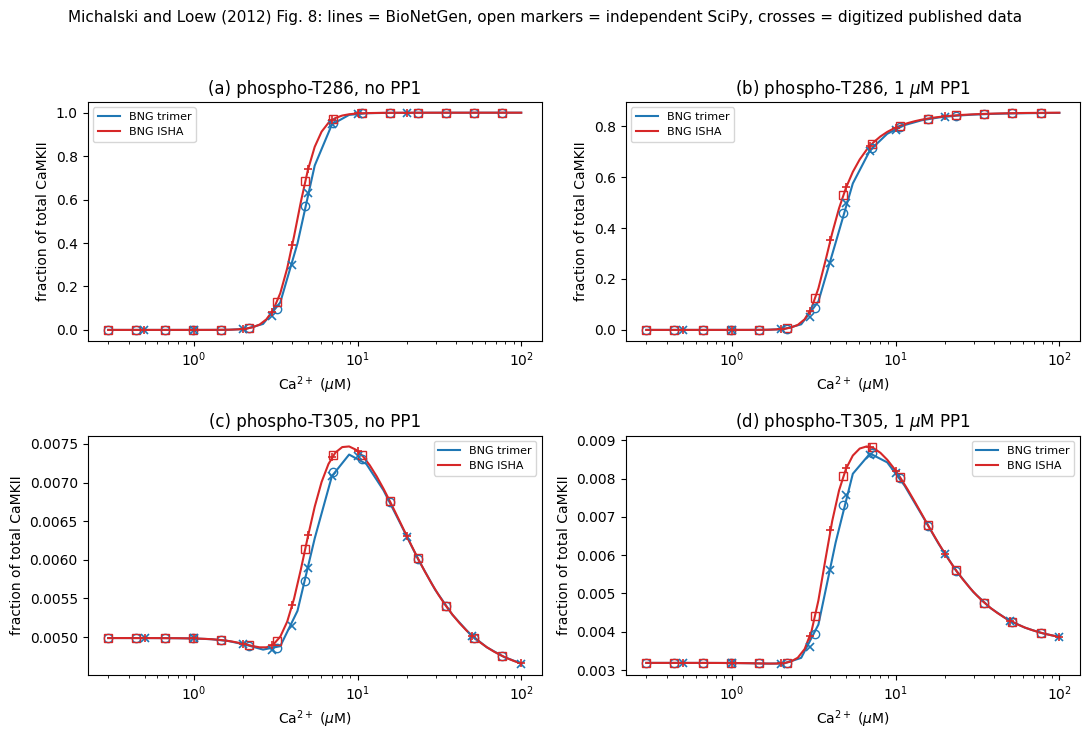

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7.5))
COL = plt.rcParams["axes.prop_cycle"].by_key()["color"]
grid = np.logspace(np.log10(0.3), 2, 45)

for k, (panel, key, pp1, t_end, _) in enumerate(PANELS):
    a = ax.flat[k]
    scan = {"a": trimer_nopp1, "b": trimer_pp1, "c": trimer_nopp1, "d": trimer_pp1}[panel]
    iscan = {"a": isha_nopp1, "b": isha_pp1, "c": isha_nopp1, "d": isha_pp1}[panel]
    col_bng = "Frac_pT286" if key == "pT286" else "Frac_pT305"
    a.semilogx(scan["Ca_uM"], scan[col_bng], "-", lw=1.5, color=COL[0], label="BNG trimer")
    a.semilogx(iscan["Ca_uM"], iscan[col_bng], "-", lw=1.5, color=COL[3], label="BNG ISHA")
    ind = np.array([solve_ring6(3, {**PAR, "Ca": float(c), "PP1": pp1}, t_end)[key] for c in grid])
    a.semilogx(grid[::3], ind[::3], "o", mfc="none", mec=COL[0], ms=6)
    indi = np.array([solve_isha6({**PAR, "Ca": float(c), "PP1": pp1}, t_end)[key] for c in grid])
    a.semilogx(grid[::3], indi[::3], "s", mfc="none", mec=COL[3], ms=6)
    for who, col, mark in (("trimer", COL[0], "x"), ("isha", COL[3], "+")):
        cr, yr = digitized(f"fig8{panel}_{who}")
        a.semilogx(cr, yr, mark, color=col, ms=6, mew=1.2)
    ttl = {"a": "(a) phospho-T286, no PP1", "b": r"(b) phospho-T286, 1 $\mu$M PP1",
           "c": "(c) phospho-T305, no PP1", "d": r"(d) phospho-T305, 1 $\mu$M PP1"}[panel]
    a.set(xlabel=r"Ca$^{2+}$ ($\mu$M)", ylabel="fraction of total CaMKII", title=ttl)
    a.legend(fontsize=8)

fig.suptitle("Michalski and Loew (2012) Fig. 8: lines = BioNetGen, open markers = "
             "independent SciPy, crosses = digitized published data", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(HERE / "verify_michalski2012_six_state.png", dpi=150)
plt.show()

## 5. Summary

In [10]:
print("Model-specification verification (BioNetGen vs independent SciPy)")
for label, err in SUMMARY:
    print(f"  {label:52s} {err:.3e}")
worst = max(e for _, e in SUMMARY)
print(f"  worst case: {worst:.3e}")
assert worst < 1e-5

print("\nReported-data verification (vs digitized Fig. 8)")
for label, dev, tol in FIGERR:
    print(f"  {label:34s} max deviation {dev:.5f}  tol {tol:.0e}  "
          f"{'OK' if dev <= tol else 'OVER TOLERANCE'}")
assert all(dev <= tol for _, dev, tol in FIGERR)
print("\nAll checks passed.")

Model-specification verification (BioNetGen vs independent SciPy)
  trimer, no PP1, 10 s                                 2.953e-08
  trimer, 1 uM PP1, 200 s                              2.372e-08
  ISHA, no PP1, 10 s                                   3.274e-08
  ISHA, 1 uM PP1, 200 s                                3.224e-08
  worst case: 3.274e-08

Reported-data verification (vs digitized Fig. 8)
  Fig. 8a trimer                     max deviation 0.00094  tol 4e-03  OK
  Fig. 8a isha                       max deviation 0.00021  tol 4e-03  OK
  Fig. 8b trimer                     max deviation 0.00278  tol 4e-03  OK
  Fig. 8b isha                       max deviation 0.00002  tol 4e-03  OK
  Fig. 8c trimer                     max deviation 0.00000  tol 4e-05  OK
  Fig. 8c isha                       max deviation 0.00000  tol 4e-05  OK
  Fig. 8d trimer                     max deviation 0.00003  tol 4e-05  OK
  Fig. 8d isha                       max deviation 0.00000  tol 4e-05  OK
  Fig. 8